**Лабораторная работа №3. Геометрические преобразования изображений**

Выполнили студенты группы 932302: Лебёдкин Владислав и Травкова Ирина

Вариант 4

In [2]:
#импорт библиотек
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

(np.float64(-0.5), np.float64(739.5), np.float64(739.5), np.float64(-0.5))

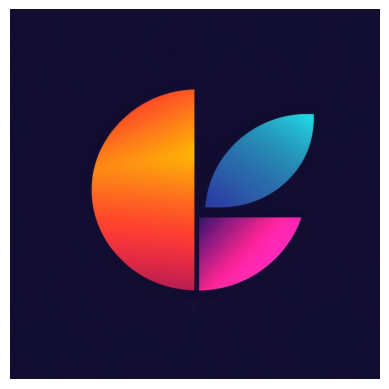

In [3]:
#чтение изображения
original_image = cv2.imread("abstract.jpg")
changing_image = cv2.cvtColor(original_image,cv2.COLOR_BGR2RGB)
plt.imshow(changing_image)
plt.axis("off")

### 1. Масштабировать изображение в 0.25 раза (уменьшить в 4 раза).

Для уменьшения изображения в 4 раза используется `cv2.resize()`: **fx, fy** - коэффициенты масштабирования по ширине и высоте; флаг **interpolation**- необязательный параметр, отвечающий за метод интерполяции. `cv2.INTER_LINEAR` отвечает за билинейную интерполяцию (Общее изменение размера)

In [4]:
resized_025 = cv2.resize(changing_image, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_LINEAR)

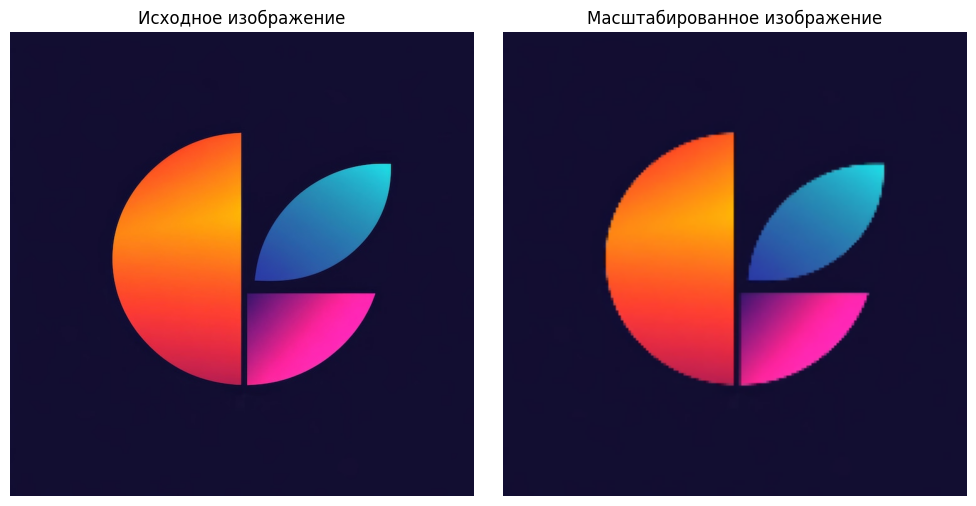

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(resized_025)
ax2.set_title('Масштабированное изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()


### 2. Повернуть изображение на 180°.

Вращение изображения относится к **аффинным преобразованиям**, которые сохраняют параллельность прямых, коллинеарность точек и отношение длин отрезков. 

Сначала вычисляем координаты центра изображения, а затем с помощью `cv2.getRotationMatrix2D(center, angle, scale)` формируем матрицу аффинного преобразования для поворота, где: 

* center - центр изображения, 
* angle - угол поворота в градусах (**180**). В OpenCV положительное значение означает поворот **против часовой стрелки**, но для $180^\circ$ направление симметрично. 
* scale — коэффициент масштабирования (**1.0**), чтобы сохранить исходные пропорции. 

Функция `cv2.warpAffine(img, M, (w, h))` применяет преобразование. Она использует **обратное отображение координат** и билинейную интерполяцию по умолчанию, что гарантирует отсутствие «дыр» и артефактов в результирующем массиве.

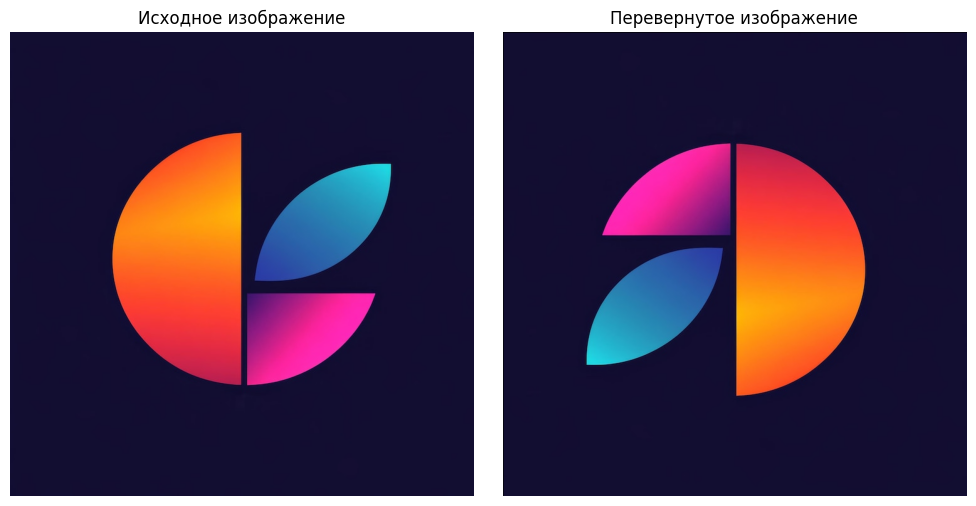

In [6]:
#вычисляем координаты центра изображения
h, w = changing_image.shape[:2]
center = (w // 2, h // 2)

#формируем матрицу аффинного преобразования для поворота
M_rot = cv2.getRotationMatrix2D(center, 180, 1.0)

#применяем преобразование
rotated_180 = cv2.warpAffine(changing_image, M_rot, (w, h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(rotated_180)
ax2.set_title('Перевернутое изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()

### 3. Сместить изображение на 150 пикселей вправо.

In [ ]:
matrix = np.float32([1, 0, 150,
          0, 1, 0])

shifted_image = cv2.warpAffine(changing_image,matrix,(w,h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(changing_image)
ax1.set_title(f'Исходное изображение')
ax1.axis('off')


ax2.imshow(shifted_image)
ax2.set_title('Сдвинутое изображение')
ax2.axis('off')
plt.tight_layout()
plt.show()

error: OpenCV(5.0.0) :-1: error: (-5:Bad argument) in function 'warpAffine'
> Overload resolution failed:
>  - M is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'M'
